# Árvore de Decisão — preditores do desfecho

Modelo interpretável (profundidade limitada) para o desfecho padronizado.

In [1]:
from pathlib import Path

import pandas as pd

from tcr_community.multivariate.decision_tree import (
    feature_importance_table,
    fit_decision_tree,
    prepare_tree_features,
    tree_text_rules,
)
from tcr_community.pipeline.prepare_data import PROCESSED_PATH, prepare_data

if not Path(PROCESSED_PATH).exists():
    prepare_data()

df = pd.read_parquet(PROCESSED_PATH)
x, y = prepare_tree_features(df)
y.value_counts()

desfecho_padronizado
OBITO            166
ALTA              21
TRANSFERENCIA     15
OUTRO              2
DESCONHECIDO       1
Name: count, dtype: int64

In [2]:
result = fit_decision_tree(x, y, max_depth=4)
print(f"train={result.train_accuracy:.3f} test={result.test_accuracy:.3f}")
feature_importance_table(result)

train=0.908 test=0.808


,feature,importance
0,escala_apache_ii,0.528307
1,cuidados_paliativos_SIM,0.224132
2,procedimento_cirurgico_SIM,0.088637
3,cuidados_paliativos_NAO,0.080929
4,comorbidades_SIM,0.036291
5,drogas_vasoativas_SIM,0.029692
6,ventilacao_mecanica_NAO,0.012012
7,comorbidades_NAO,0.000000
8,ventilacao_mecanica_AA,0.000000
9,transfusao_sanguinea_NAO,0.000000


## Visualização da árvore

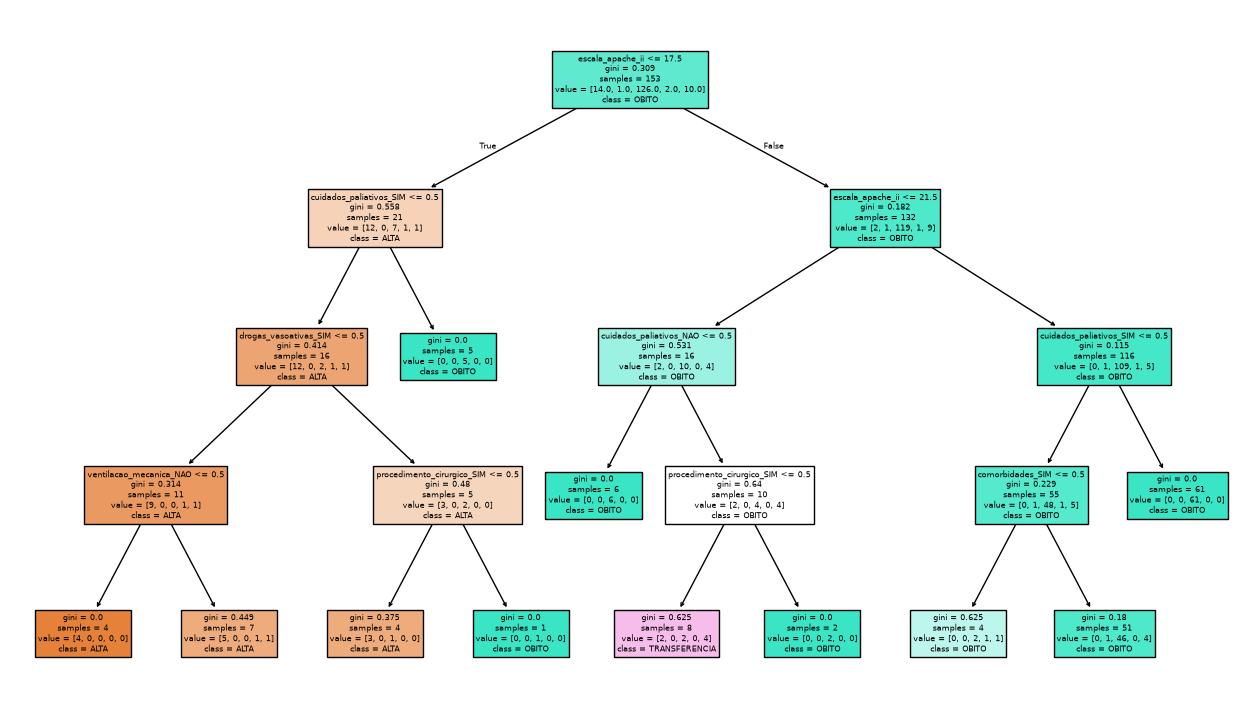

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(16, 9))
plot_tree(
    result.model,
    feature_names=result.feature_names,
    class_names=result.class_names,
    filled=True,
    ax=ax,
)
plt.show()

In [4]:
print(tree_text_rules(result))

|--- escala_apache_ii <= 17.50
|   |--- cuidados_paliativos_SIM <= 0.50
|   |   |--- drogas_vasoativas_SIM <= 0.50
|   |   |   |--- ventilacao_mecanica_NAO <= 0.50
|   |   |   |   |--- class: ALTA
|   |   |   |--- ventilacao_mecanica_NAO >  0.50
|   |   |   |   |--- class: ALTA
|   |   |--- drogas_vasoativas_SIM >  0.50
|   |   |   |--- procedimento_cirurgico_SIM <= 0.50
|   |   |   |   |--- class: ALTA
|   |   |   |--- procedimento_cirurgico_SIM >  0.50
|   |   |   |   |--- class: OBITO
|   |--- cuidados_paliativos_SIM >  0.50
|   |   |--- class: OBITO
|--- escala_apache_ii >  17.50
|   |--- escala_apache_ii <= 21.50
|   |   |--- cuidados_paliativos_NAO <= 0.50
|   |   |   |--- class: OBITO
|   |   |--- cuidados_paliativos_NAO >  0.50
|   |   |   |--- procedimento_cirurgico_SIM <= 0.50
|   |   |   |   |--- class: TRANSFERENCIA
|   |   |   |--- procedimento_cirurgico_SIM >  0.50
|   |   |   |   |--- class: OBITO
|   |--- escala_apache_ii >  21.50
|   |   |--- cuidados_paliativos_SIM <=